In [1]:
# ======================================================
# Estudo 1 - Espectograma e MFCCs
# ======================================================

In [2]:
import sys
import subprocess

# Caminho exato do Python 3.10
python_310 = r"c:\Users\pm26937\AppData\Local\Python\pythoncore-3.10-64\python.exe"

# Lista dos pacotes necessários
packages = [
    "numpy==1.26.4",
    "scipy==1.10.1",
    "librosa==0.10.1",
    "tensorflow==2.15.0",
]

# Instala somente se faltando e garante que usa o Python 3.10
for pkg in packages:
    print(f"Instalando {pkg}...")
    subprocess.check_call([python_310, "-m", "pip", "install", pkg])


Instalando numpy==1.26.4...
Instalando scipy==1.10.1...
Instalando librosa==0.10.1...
Instalando tensorflow==2.15.0...


In [3]:
###imports
import numpy as np # Computação numérica e operações de matriz
import librosa # Processamento de áudio e música
import librosa.display # Visualização de dados
import matplotlib.pyplot as plt
import IPython.display as ipd # Exibição interativa de áudio em notebooks Jupyter
from scipy.io import wavfile # Operações de I/O de arquivos de áudio
import pandas as pd # Manipulação e análise de dados
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import shuffle
from tensorflow.keras import layers, models, callbacks, utils
from tqdm import tqdm
import joblib

In [4]:
csv_path = r"C:\Users\pm26937\Downloads\TCC_AudioCNN\script\dados_preparados2.csv"

In [5]:
df = pd.read_csv(csv_path)
df.head()

,caminho,numero,origem,tipo
0,C:\Users\pm26937\Downloads\trabalho4\data\47\6...,6,normal,treino
1,C:\Users\pm26937\Downloads\trabalho2\UASpeech_...,nao_numero,disartria,treino
2,C:\Users\pm26937\Downloads\trabalho4\data\48\6...,6,normal,treino
3,C:\Users\pm26937\Downloads\trabalho4\data\53\2...,2,normal,treino
4,C:\Users\pm26937\Downloads\trabalho4\data\52\0...,0,normal,treino


In [6]:
#Usando primeiro áudio para estudo
audio_path = df.loc[0, "caminho"]
#print(audio_path)

In [7]:
y, sr = librosa.load(audio_path)
#librosa.load()lê o arquivo de áudio e retorna duas variáveis --> 
# y: A série temporal de áudio como uma matriz numpy 
# sr: A taxa de amostragem do áudio

In [8]:
y #y: A série temporal de áudio como uma matriz numpy

array([-0.00039097, -0.00058008, -0.00053936, ..., -0.00038667,
       -0.00040052, -0.0004087 ], dtype=float32)

In [9]:
sr #sr: A taxa de amostragem do áudio 
#(por padrão, o librosa reamostra o áudio para 22050 H)

22050

In [10]:
#propriedades do audio
duracao = librosa.get_duration(y=y, sr=sr)
print(f"Audio duracao: {duracao:.2f} segundos")
print(f"Taxa de amostragem/numero de amostras por segundo: {sr} Hz")
print(f"Numero de amostras/total de pontos de dados: {len(y)}")
print(f"Forma: {y.shape}")

Audio duracao: 0.83 segundos
Taxa de amostragem/numero de amostras por segundo: 22050 Hz
Numero de amostras/total de pontos de dados: 18354
Forma: (18354,)


In [11]:
#ouvir o audio para estuda-lo
ipd.display(ipd.Audio(y, rate=sr))

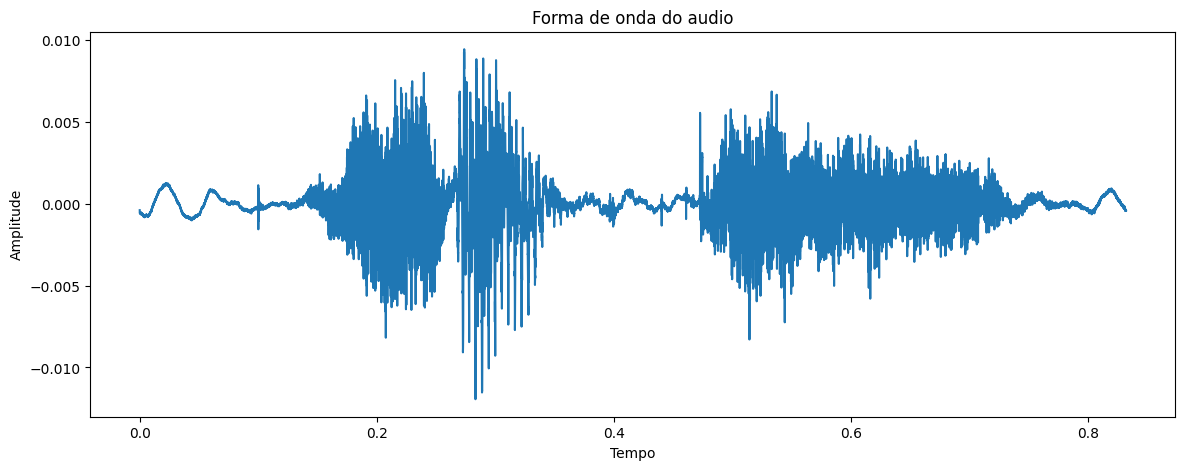

In [12]:
# Visualizando a forma de onda - Ela mostra a amplitude do sinal ao longo do tempo.
plt.figure(figsize=(14, 5))
plt.plot(np.linspace(0, len(y)/sr, len(y)), y)
plt.title("Forma de onda do audio")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")
plt.show()

In [13]:
#Enquanto a forma de onda mostra a amplitude ao longo do tempo, um espectrograma 
#mostra como o conteúdo de frequência do sinal muda ao longo do tempo.
#É uma representação 2D com o tempo no eixo x, a frequência no eixo y e a cor 
# representando a intensidade de cada frequência em cada ponto no tempo.

#Para calcular o espectrograma, utilizamos a Transformada de Fourier de Curto Prazo (STFT)
#A STFT divide o sinal de áudio em quadros curtos sobrepostos e calcula a 
#Transformada de Fourier para cada quadro.
#Isso nos fornece uma representação variável no tempo do conteúdo de frequência do áudio.

In [14]:
######### Espectograma ######

In [15]:
#Espectograma
D = librosa.stft(y)  # STFT de y
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)  # Converte para escala dB

#D
#S_db

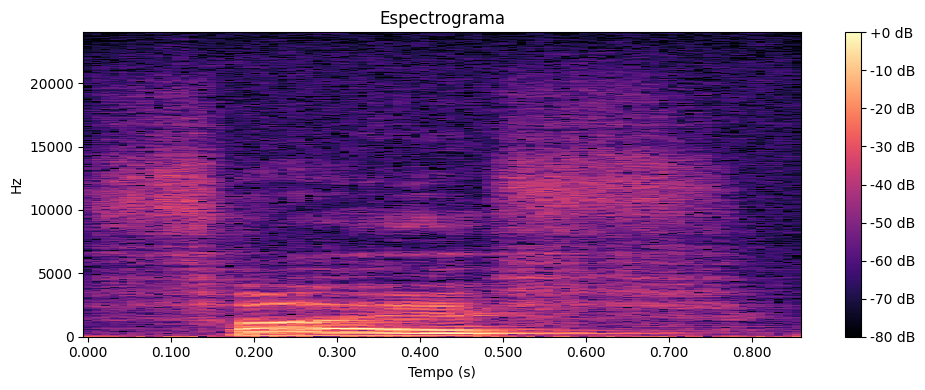

In [16]:
#MFCC para o trabalho escrtito
# Escolher um áudio de dígito representativo
audio_path = df[df['numero'] == '5'].iloc[0]['caminho']  # ex: dígito 5
y, sr = librosa.load(audio_path, sr=None)

D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma')
plt.xlabel('Tempo (s)')
plt.ylabel('Hz')
plt.tight_layout()
plt.savefig('espectrograma.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

In [17]:
######### MFCC #########

In [18]:
#espectrograma Mel
#é semelhante a um espectrograma regular, mas a escala de frequência é convertida 
# para a escala Mel
#representa melhor a percepção auditiva humana

In [19]:
# Espectograma Mel
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db_mel = librosa.power_to_db(S, ref=np.max)

In [20]:
#print(f"Espectograma comum: {D}")
#print(f"Novo espectograma: {S}")
#S_db_mel

In [21]:
#Comparando em escalas db
print(f"Espectograma comum: {S_db}")
print(f"Novo espectograma: {S_db_mel}")

Espectograma comum: [[-24.93432  -26.152534 -28.323719 ... -27.736088 -34.98343  -23.274158]
 [-26.173306 -22.639242 -23.11786  ... -26.050423 -24.218685 -23.736553]
 [-30.454582 -26.020596 -25.514597 ... -30.267315 -30.517145 -26.448004]
 ...
 [-71.02812  -69.87908  -80.       ... -69.74626  -73.08446  -80.      ]
 [-69.778625 -67.336426 -78.16678  ... -67.32269  -68.81946  -72.09531 ]
 [-69.38527  -65.38597  -68.73047  ... -67.31941  -80.       -70.18205 ]]
Novo espectograma: [[-27.158232 -23.421856 -23.639692 ... -27.021933 -25.551348 -24.34649 ]
 [-33.388542 -29.457209 -28.892508 ... -34.003128 -33.308903 -28.512362]
 [-38.996536 -36.472256 -36.90802  ... -51.138477 -40.625732 -34.643806]
 ...
 [-66.927124 -65.60784  -66.57611  ... -65.877266 -66.24023  -69.65262 ]
 [-70.79304  -68.12842  -68.066475 ... -68.55497  -69.04584  -70.8363  ]
 [-73.86473  -70.60119  -69.27907  ... -69.92452  -70.60518  -72.62321 ]]


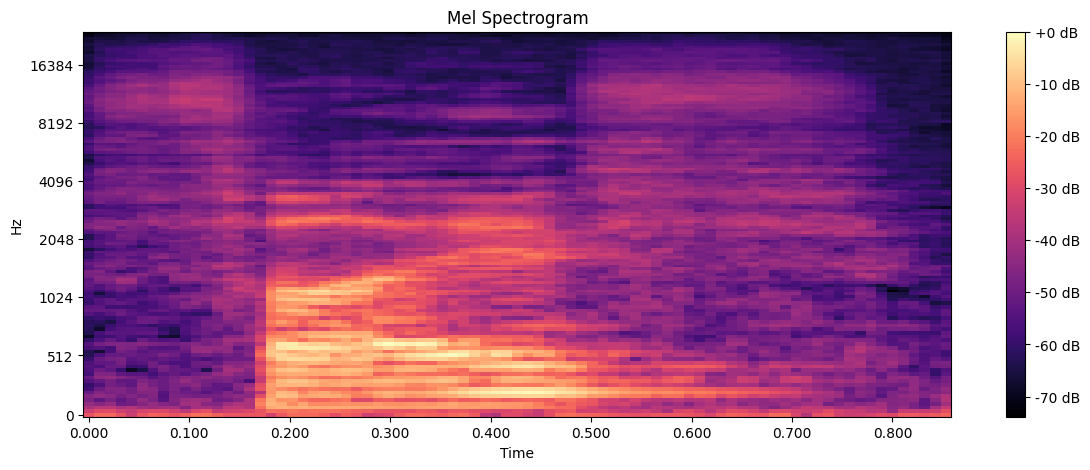

In [22]:
# Plot espectograma Mel - ver o outro para comparar
plt.figure(figsize=(14, 5))
librosa.display.specshow(S_db_mel, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.show()

In [23]:
#MFCCs
n_mfcc = 13
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

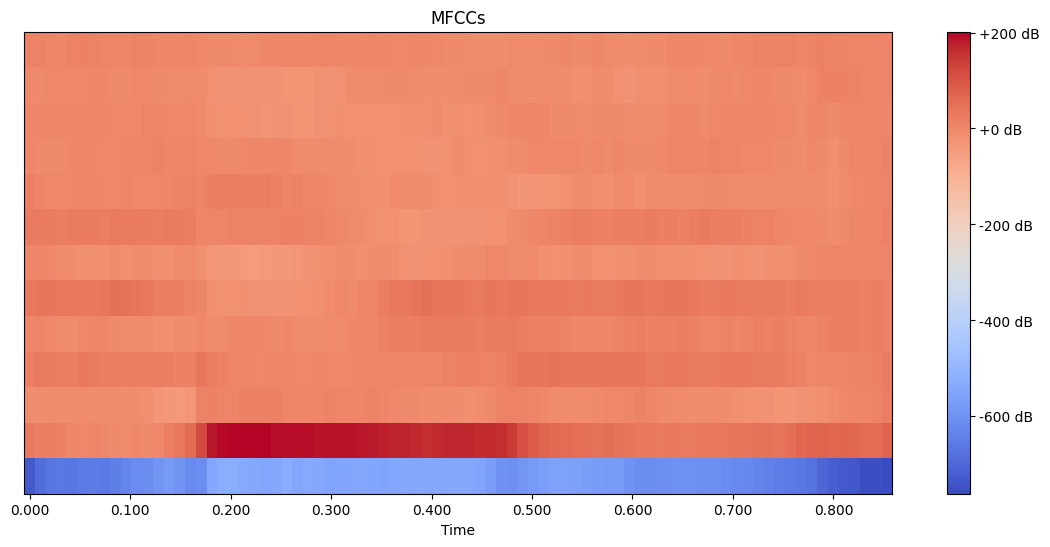

In [24]:
# Visualizar MFCCs
plt.figure(figsize=(14, 6))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('MFCCs')
plt.show()

#A intensidade da cor representa a magnitude de cada coeficiente em cada ponto de tempo
#Os coeficientes mais baixos (parte inferior do gráfico) representam o envelope 
# espectral geral, enquanto os coeficientes mais altos representam detalhes espectrais
#  mais finos.


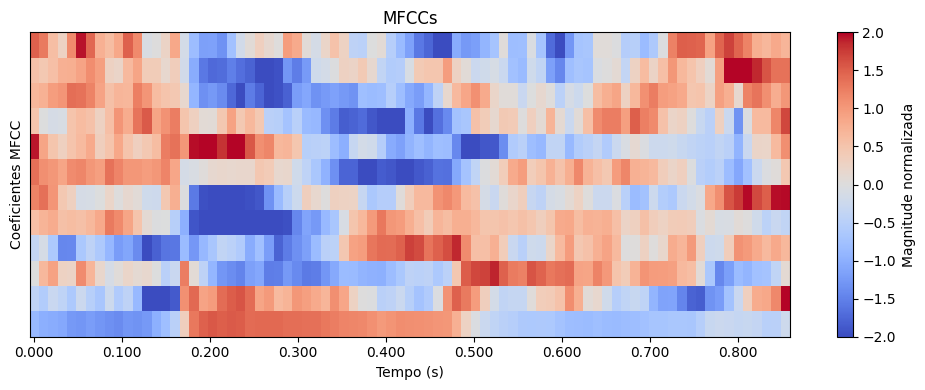

In [25]:
# MFCC para o trabalho escrito - Figura 3.2
audio_path = df[df['numero'] == '5'].iloc[0]['caminho']
y, sr = librosa.load(audio_path, sr=None)

n_mfcc = 13
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

# Normaliza cada coeficiente individualmente (z-score por linha)
mfccs_norm = np.zeros_like(mfccs[1:, :])
for i in range(mfccs_norm.shape[0]):
    linha = mfccs[i+1, :]
    mfccs_norm[i] = (linha - linha.mean()) / (linha.std() + 1e-9)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs_norm, sr=sr, x_axis='time',
                            cmap='coolwarm', vmin=-2, vmax=2)
plt.colorbar(label='Magnitude normalizada')
plt.title('MFCCs')
plt.xlabel('Tempo (s)')
plt.ylabel('Coeficientes MFCC')
plt.tight_layout()
plt.show()

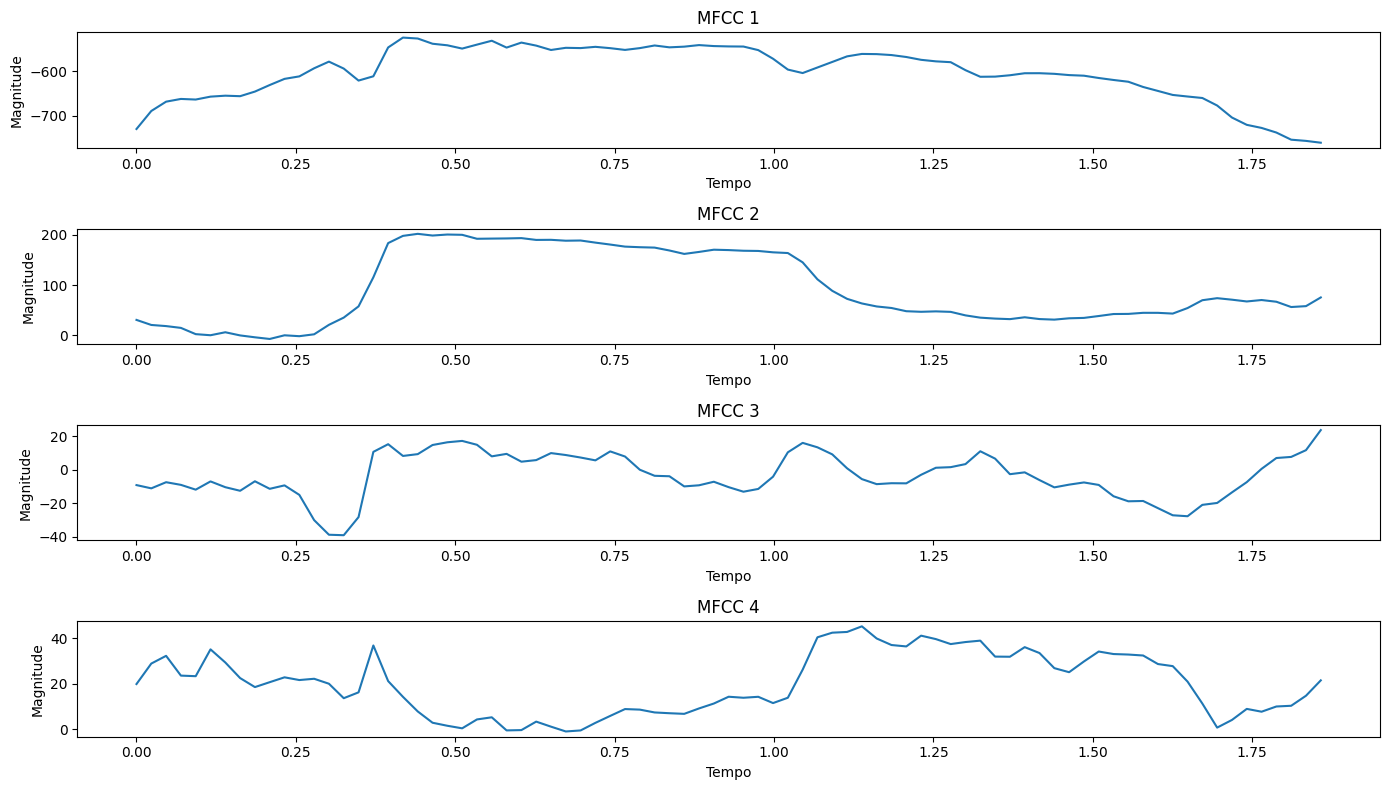

In [26]:
#Ver como o espectograma reage ao longo do tempo
plt.figure(figsize=(14, 8))
for i in range(4):  # Plotar os 4 primeiros MFCCs
    plt.subplot(4, 1, i+1)
    plt.plot(librosa.times_like(mfccs), mfccs[i])
    plt.title(f'MFCC {i+1}')
    plt.xlabel('Tempo')
    plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

#O MFCC 1 geralmente se correlaciona com a energia geral do sinal.
#MFCCs de ordem superior representam detalhes espectrais cada vez mais finos.

In [27]:
# ======================================================
# CNN - Extrair MFCCs em matriz, montar X e treinar CNN (Keras)
# ======================================================

In [28]:
# Parâmetros (ajuste conforme quiser)
SR = 16000 # taxa de amostragem para carregamento padronizado (reamostramos se necessário)
N_MFCC = 40 # número de coeficientes MFCC a extrair
MAX_FRAMES = 128 # número máximo de frames (tempo) que iremos usar para pad/trunc (ajustável)

In [29]:
# CSV já criado no passo anterior
csv_path = r"C:\Users\pm26937\Downloads\TCC_AudioCNN\script\dados_preparados2.csv"
df = pd.read_csv(csv_path)
print(f"Total de registros no CSV: {len(df)}")

Total de registros no CSV: 71260


In [30]:
# Função que extrai MFCC como matriz (n_mfcc x frames) - sem colapsar com mean
# código sem normalizar 
#retorna y com SR numeros no total (estamos usando SR = 16000) - cada numero é a amplitude naquele milissegundo
'''
def extrair_mfcc_matriz(caminho, sr_target=SR, n_mfcc=N_MFCC):
    try:
        y, sr = brosa.load(caminho, sr=sr_target)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # mfcc tem shape (n_mfcc, frames)
        return mfcc

    except Exception as e:
        print(f"Erro no arquivo {caminho}: {e}")li
        # retorna uma matriz pequena que será padronizada depois
        return np.zeros((n_mfcc, 1))
'''
#normalizando
def extrair_mfcc_matriz(caminho, sr_target=SR, n_mfcc=N_MFCC):
    try:
        y, sr = librosa.load(caminho, sr=sr_target)
        mf = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mf = (mf - np.mean(mf)) / (np.std(mf) + 1e-9)
        return mf
    except Exception as e:
        print(f"Erro no arquivo {caminho}: {e}")
        return np.zeros((n_mfcc, 1))



In [31]:
# Extraindo MFCCs (como matrizes) - demora
mfcc_list = [] # lista de matrizes (n_mfcc, frames)
paths = df['caminho'].tolist()
print("Extraindo MFCCs (matriz) de cada áudio...")
for caminho in tqdm(paths):
    mf = extrair_mfcc_matriz(caminho)
    mfcc_list.append(mf)

Extraindo MFCCs (matriz) de cada áudio...


  2%|▏         | 1344/71260 [00:10<08:50, 131.69it/s]C:\Users\pm26937\AppData\Local\Temp\ipykernel_31764\4121020304.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(caminho, sr=sr_target)
c:\Users\pm26937\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\librosa\core\audio.py:183: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  2%|▏         | 1372/71260 [00:10<09:04, 128.29it/s]

Erro no arquivo C:\Users\pm26937\Downloads\trabalho2\UASpeech_noisereduce_C\UASpeech\audio\noisereduce\CM12\._CM12_B1_C2_M8.wav: 


 63%|██████▎   | 44808/71260 [06:59<04:41, 93.84it/s] 

Erro no arquivo C:\Users\pm26937\Downloads\trabalho2\UASpeech_noisereduce_FM\UASpeech\audio\noisereduce\F03\._F03_B1_C2_M8.wav: 


 71%|███████   | 50485/71260 [08:18<04:44, 73.04it/s] 

Erro no arquivo C:\Users\pm26937\Downloads\trabalho2\UASpeech_noisereduce_FM\UASpeech\audio\noisereduce\M01\._M01_B1_C1_M3.wav: 


100%|██████████| 71260/71260 [12:47<00:00, 92.83it/s]


In [32]:
mfcc_list

[array([[-7.619431  , -7.6819506 , -7.589776  , ..., -6.8398633 ,
         -7.417526  , -7.6534567 ],
        [ 0.9727094 ,  0.7627968 ,  0.48840111, ...,  0.39350554,
          0.62159616,  0.78640753],
        [ 0.39157447,  0.44564915,  0.6006495 , ...,  0.54246014,
          0.5391846 ,  0.54770595],
        ...,
        [ 0.13515125,  0.15232828,  0.16918921, ...,  0.080441  ,
          0.10041527,  0.09814963],
        [ 0.1291117 ,  0.10965842,  0.11344486, ...,  0.11016311,
          0.09799976,  0.14265518],
        [ 0.16759168,  0.16759627,  0.14868937, ...,  0.09883708,
          0.07939746,  0.1182501 ]], dtype=float32),
 array([[-5.60455227e+00, -5.15718174e+00, -5.56387138e+00, ...,
         -6.16013765e+00, -5.31520653e+00, -5.03642035e+00],
        [ 1.22844338e+00,  1.28305054e+00,  1.30937171e+00, ...,
          1.26208103e+00,  1.36874306e+00,  1.56132388e+00],
        [ 2.24561602e-01,  1.76705599e-01,  2.18731806e-01, ...,
          3.72632325e-01,  3.55091840e-01

In [33]:
# Shape do primeiro MFCC cru - verificando que é uma matriz
print("Exemplo de MFCC (matriz) do primeiro arquivo:", mfcc_list[0].shape)
#deve ser da forma: (num de coef MFCC , quant. de frames)

Exemplo de MFCC (matriz) do primeiro arquivo: (40, 27)


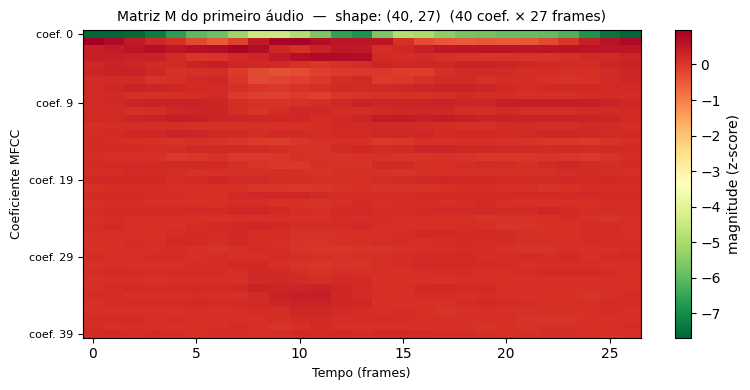

Shape: (40, 27) → 40 coeficientes × 27 frames


In [34]:
# ======================================================
# Visualização da matriz M do primeiro MFCC (bruta)
# ======================================================

import matplotlib.pyplot as plt

mfcc_exemplo = mfcc_list[0]  # matriz (40, 27) do primeiro áudio

fig, ax = plt.subplots(figsize=(8, 4))
img = ax.imshow(mfcc_exemplo, aspect='auto', origin='upper', cmap='RdYlGn_r')
ax.set_title(f'Matriz M do primeiro áudio  —  shape: {mfcc_exemplo.shape}  (40 coef. × {mfcc_exemplo.shape[1]} frames)', fontsize=10)
ax.set_xlabel('Tempo (frames)', fontsize=9)
ax.set_ylabel('Coeficiente MFCC', fontsize=9)
ax.set_yticks([0, 9, 19, 29, 39])
ax.set_yticklabels(['coef. 0', 'coef. 9', 'coef. 19', 'coef. 29', 'coef. 39'], fontsize=8)
plt.colorbar(img, ax=ax, label='magnitude (z-score)')
plt.tight_layout()
plt.savefig('figura1_mfcc_bruta.jpg', dpi=150, bbox_inches='tight',
            facecolor='white', format='jpg', pil_kwargs={'quality': 88})
plt.show()
print(f"Shape: {mfcc_exemplo.shape} → {mfcc_exemplo.shape[0]} coeficientes × {mfcc_exemplo.shape[1]} frames")

In [35]:
# %% 
# Definindo o numero de frames:
#-----------
# HISTOGRAMA DOS FRAMES #
# Áudios muito longos pode puxar o máximo para cima

#-----------
# USANDO O MIN #
# Isso achataria todos os MFCCs para o tamanho do menor arquivo --> perda gigante de informação --> acurácia despenca

#-----------
# MEDIANA DOS FRAMES #
# MAX_FRAMES = median(frames) 
# Melhora a estabilidade pois ignora valores extremos
# funciona bem quando áudios têm distribuições simétricas

#-----------
# PERCENTIL 90 (P90) #
# MAX_FRAMES = np.percentile(frames, 90)
# mantém 90% dos áudios quase intactos e corta apenas os 10% mais longos
# equilibra informação x tamanho da CNN

Min: 1
Mediana: 48.0
P90: 95.0
P95: 126.0
Máximo: 1780


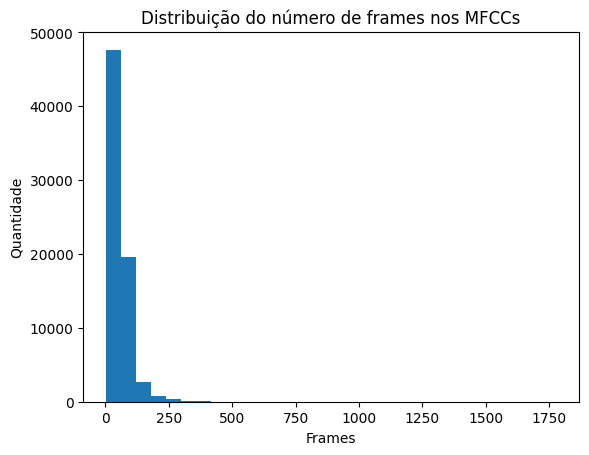

In [36]:
# calcular quantidade de frames por MFCC
frames_list = [m.shape[1] for m in mfcc_list]

print("Min:", np.min(frames_list))
print("Mediana:", np.median(frames_list))
print("P90:", np.percentile(frames_list, 90))
print("P95:", np.percentile(frames_list, 95))
print("Máximo:", np.max(frames_list))

plt.hist(frames_list, bins=30)
plt.title("Distribuição do número de frames nos MFCCs")
plt.xlabel("Frames")
plt.ylabel("Quantidade")
plt.show()

In [37]:
# %% 
# Análise dos resultados:
#-----------
# USANDO O MIN #
# NÃO --> min é 10 frames --> CNN teria pouca informação --> modelo fraco

#-----------
# MEDIANA DOS FRAMES #
# É POSSIVEL já que mediana = 21 --> Melhor para experimentos simples
# Rápido e pouco custo 
# Perde muita informação dos áudios maiores --> CNN limitada

#-----------
# PERCENTIL 90 ou 95 #
# Boas opções pois mantém a informação sem truncar demais, pouca perda e não explode a memória

In [38]:
#Padronizar MFCCs usando P95 = 50 frames
MAX_FRAMES = int(np.percentile(frames_list, 90))
print("Usando MAX_FRAMES =", MAX_FRAMES)

def pad_or_truncate(mfcc, max_frames=MAX_FRAMES):
    """
    Recebe uma matriz MFCC (n_mfcc, frames)
    e devolve (n_mfcc, max_frames)
    """
    n_mfcc, frames = mfcc.shape
    
    if frames >= max_frames:
        mf = mfcc[:, :max_frames]
    else:
        mf = np.zeros((n_mfcc, max_frames))
        mf[:, :frames] = mfcc

#normalizando
    mf_mean = np.mean(mf)
    mf_std = np.std(mf) + 1e-9
    mf = (mf - mf_mean) / mf_std  
    
    return mf

Usando MAX_FRAMES = 95


In [39]:
# Aplicando pad/trunc em todo mfcc_list
X_mfcc = np.array([pad_or_truncate(m) for m in mfcc_list])

print("Novo shape de X_mfcc:", X_mfcc.shape)
# espera: (num_arquivos, 40, 64)

Novo shape de X_mfcc: (71260, 40, 95)


In [40]:
#### Preparar y (rótulos — dígitos de 0 a 9) - AQUI DEFINO O QUE QUERO FAZER
labels = df['numero'].tolist()
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

print("Classes:", encoder.classes_)
print("Shape de y:", y.shape)


Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'nao_numero']
Shape de y: (71260,)


In [41]:
# Separar TREINO / TESTE conforme coluna 'tipo' já tratada
# Índices
idx_treino = df[df['tipo'] == 'treino'].index
idx_teste  = df[df['tipo'] == 'teste'].index

# X e y
X_train = X_mfcc[idx_treino]
X_test  = X_mfcc[idx_teste]

y_train = y[idx_treino]
y_test  = y[idx_teste]

print("Shapes finais:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Shapes finais:
X_train: (49881, 40, 95)
y_train: (49881,)
X_test: (21379, 40, 95)
y_test: (21379,)


In [42]:
# Redimensionar para CNN: (40, 64, 1): A CNN do Keras espera imagens no formato (altura, largura, canais)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print("Novo shape X_train:", X_train.shape)
print("Novo shape X_test:", X_test.shape)

Novo shape X_train: (49881, 40, 95, 1)
Novo shape X_test: (21379, 40, 95, 1)


In [43]:
########## MODELO CNN COM 10 CLASSES + 1 (nao_numero) #############

In [44]:
input_shape = (N_MFCC, MAX_FRAMES, 1)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(11, activation="softmax")
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 40, 95, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 40, 95, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 20, 47, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 20, 47, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 20, 47, 64)        256       
 chNormalization)                                                
                                                     

In [45]:
#melhorando recall multiplicando o erro de cada classe por um peso (pois nao_numero tem mais amostras)
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {0: 1.8182182693008675, 1: 1.8182182693008675, 2: 1.8182182693008675, 3: 1.8182182693008675, 4: 1.8182182693008675, 5: 1.8182182693008675, 6: 1.8182182693008675, 7: 1.8182182693008675, 8: 1.8182182693008675, 9: 1.8182182693008675, 10: 0.18181453685242627}


In [46]:
#### TREINO ###
es = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8, # quando a validação parou de melhorar por 8 épocas seguidas, o treino é interrompido
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[es]
)


Epoch 1/40


1559/1559 [==============================] - 91s 57ms/step - loss: 1.8528 - accuracy: 0.4006 - val_loss: 1.1050 - val_accuracy: 0.7188
Epoch 2/40
1559/1559 [==============================] - 72s 46ms/step - loss: 0.9341 - accuracy: 0.6779 - val_loss: 0.7625 - val_accuracy: 0.8815
Epoch 3/40
1559/1559 [==============================] - 72s 46ms/step - loss: 0.5030 - accuracy: 0.8553 - val_loss: 0.5443 - val_accuracy: 0.8939
Epoch 4/40
1559/1559 [==============================] - 77s 49ms/step - loss: 0.3732 - accuracy: 0.8721 - val_loss: 0.4539 - val_accuracy: 0.9163
Epoch 5/40
1559/1559 [==============================] - 84s 54ms/step - loss: 0.2977 - accuracy: 0.8843 - val_loss: 0.3464 - val_accuracy: 0.9316
Epoch 6/40
1559/1559 [==============================] - 87s 56ms/step - loss: 0.2449 - accuracy: 0.9003 - val_loss: 0.2691 - val_accuracy: 0.9340
Epoch 7/40
1559/1559 [==============================] - 83s 54ms/step - loss: 0.2032 - accuracy: 0.9119 - val_loss: 0.2514

In [47]:
print(X_train[-1])

[[[-5.68456889e+00]
  [-4.45836179e+00]
  [-4.58847872e+00]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]

 [[ 1.10339943e+00]
  [ 7.84364638e-01]
  [ 8.89635545e-01]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]

 [[ 8.63342047e-01]
  [ 1.24310601e+00]
  [ 1.51235440e+00]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]

 ...

 [[ 2.39694746e-01]
  [ 3.30496493e-01]
  [ 3.52229924e-01]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]

 [[ 1.88035674e-01]
  [ 2.02461916e-01]
  [ 2.04581454e-01]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]

 [[ 2.56865340e-01]
  [ 2.53381418e-01]
  [ 2.29545400e-01]
  ...
  [ 2.92298678e-09]
  [ 2.92298678e-09]
  [ 2.92298678e-09]]]


In [48]:
print(y_train)

[ 6 10  6 ...  3  5  5]


In [49]:
pd.DataFrame(history.history)

,loss,accuracy,val_loss,val_accuracy
0,1.852790,0.400613,1.104952,0.718789
1,0.934066,0.677933,0.762535,0.881519
2,0.502972,0.855276,0.544342,0.893915
3,0.373185,0.872136,0.453914,0.916273
4,0.297733,0.884265,0.346428,0.931615
5,0.244865,0.900343,0.269113,0.934001
6,0.203176,0.911870,0.251354,0.942373
7,0.179699,0.921032,0.244410,0.934094
8,0.169265,0.926305,0.250254,0.944478
9,0.145678,0.935146,0.201959,0.949530


In [50]:
# Avaliação
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))

669/669 [==============================] - 8s 12ms/step
Acurácia: 0.9858739884933814

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1069
           1       0.99      0.99      0.99      1069
           2       0.96      1.00      0.98      1069
           3       0.98      0.99      0.98      1069
           4       0.97      0.99      0.98      1069
           5       0.99      0.96      0.98      1069
           6       0.99      1.00      0.99      1069
           7       0.98      0.98      0.98      1069
           8       0.99      0.99      0.99      1069
           9       0.99      0.99      0.99      1069
          10       0.99      0.98      0.99     10689

    accuracy                           0.99     21379
   macro avg       0.98      0.99      0.99     21379
weighted avg       0.99      0.99      0.99     21379


Matriz de Confusão:
 [[ 1064     0     0     1     0     0     0     0     0

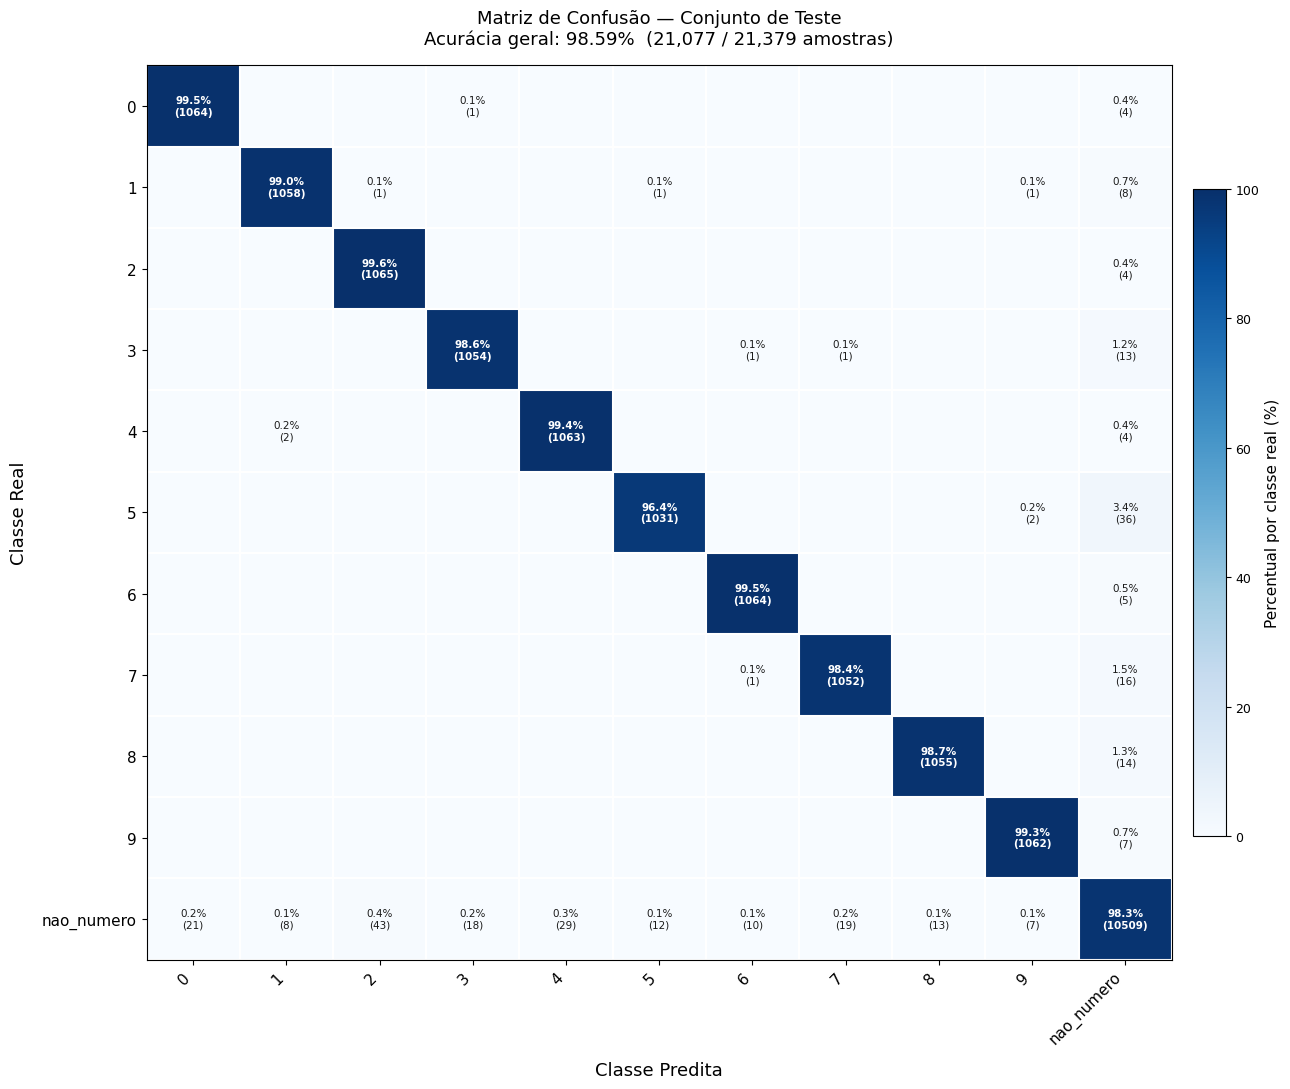

Salvo: matriz_confusao.jpg


In [51]:
from sklearn.metrics import confusion_matrix
# Imagem da matriz de confusão
#  Usar y_test e y_pred já calculados
cm = confusion_matrix(y_test, y_pred)

# Rótulos das classes (ordem do LabelEncoder)
rotulos = [str(i) for i in range(10)] + ['nao_numero']

# Normalizar para percentual por linha (recall visual)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(13, 11))

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100,
               aspect='auto', interpolation='nearest')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Percentual por classe real (%)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# Anotações em cada célula
thresh = cm_norm.max() / 2.0
for i in range(len(rotulos)):
    for j in range(len(rotulos)):
        valor_norm = cm_norm[i, j]
        valor_abs  = cm[i, j]
        cor = 'white' if valor_norm > thresh else '#1a1a1a'
        # linha 1: percentual | linha 2: absoluto (só diagonal e erros > 0)
        if valor_abs > 0:
            ax.text(j, i,
                    f'{valor_norm:.1f}%\n({valor_abs})',
                    ha='center', va='center',
                    fontsize=7.5, color=cor, fontweight='bold' if i == j else 'normal')

# Eixos
ax.set_xticks(range(len(rotulos)))
ax.set_yticks(range(len(rotulos)))
ax.set_xticklabels(rotulos, fontsize=11, rotation=45, ha='right')
ax.set_yticklabels(rotulos, fontsize=11)
ax.set_xlabel('Classe Predita', fontsize=13, labelpad=10)
ax.set_ylabel('Classe Real', fontsize=13, labelpad=10)
ax.set_title('Matriz de Confusão — Conjunto de Teste\n'
             f'Acurácia geral: {cm.diagonal().sum() / cm.sum():.2%}  '
             f'({cm.diagonal().sum():,} / {cm.sum():,} amostras)',
             fontsize=13, pad=15)

# Grid suave entre células
ax.set_xticks(np.arange(-0.5, len(rotulos), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(rotulos), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', length=0)

plt.tight_layout()
plt.savefig('matriz_confusao.jpg', dpi=150, bbox_inches='tight',
            facecolor='white', format='jpg', pil_kwargs={'quality': 90})
plt.show()
print("Salvo: matriz_confusao.jpg")


In [52]:
# Salvar modelo
model.save("modelo_cnn_digitos.h5")
joblib.dump(encoder, "label_encoder_digits.pkl")
joblib.dump(MAX_FRAMES, "max_frames.pkl")

print("Modelo e encoder salvos")


Modelo e encoder salvos


c:\Users\pm26937\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [53]:
##########testes de modelo#######

In [54]:
import sounddevice as sd
import tensorflow as tf
import IPython.display as ipd

FS = 16000
N_MFCC = 40
MAX_FRAMES = joblib.load("max_frames.pkl")
DURATION = 2.0

In [55]:
def pad_or_truncate(mfcc, max_frames=MAX_FRAMES): #igual treino
    n_mfcc, frames = mfcc.shape

    if frames >= max_frames:
        mf = mfcc[:, :max_frames]
    else:
        mf = np.zeros((n_mfcc, max_frames))
        mf[:, :frames] = mfcc

    # normalização igual ao treino
    mf = (mf - np.mean(mf)) / (np.std(mf) + 1e-9)
    return mf

In [119]:
#gravar audio de teste
print("🎙️ Gravando áudio por 3 segundo...")
audio = sd.rec(int(DURATION * FS), samplerate=FS, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()

'''
# plot audio
plt.figure(figsize=(10, 3))
plt.plot(audio)
plt.title("Áudio gravado (forma de onda)")
plt.show()
'''

ipd.display(ipd.Audio(audio, rate=FS))

# EXTRAIR MFCC + NORMALIZA
mf = librosa.feature.mfcc(y=audio, sr=FS, n_mfcc=N_MFCC)
mf = pad_or_truncate(mf)
# Ajuste do formato
mf = mf.reshape(1, N_MFCC, MAX_FRAMES, 1)

#roda modelo
MODEL_PATH = "modelo_cnn_digitos.h5"
ENCODER_PATH = "label_encoder_digits.pkl"

#
pred = model.predict(mf)[0]
classe_idx = np.argmax(pred)
classe = encoder.inverse_transform([classe_idx])[0]

print("RESULTADO DA CLASSIFICAÇÃO:")
print("=============")
print(f"Probabilidades: {pred}")
print(f"\nO modelo classificou como: **{classe}**")
print("=============\n")



🎙️ Gravando áudio por 3 segundo...


1/1 [==============================] - 0s 42ms/step
RESULTADO DA CLASSIFICAÇÃO:
Probabilidades: [8.1723811e-06 4.7843540e-05 4.3616447e-07 3.0892585e-05 1.9786805e-04
 9.6442102e-07 6.7784832e-08 4.0244399e-07 1.3964725e-05 6.2573113e-06
 9.9969304e-01]

O modelo classificou como: **nao_numero**



In [57]:
# ======================================================
# RESUMO DO EXPERIMENTO - PARA RELATO DO TCC
# ======================================================

print("\n" + "="*60)
print("RESUMO DO EXPERIMENTO - CNN PARA RECONHECIMENTO DE DÍGITOS")
print("="*60)

# -------------------------
# Informações do dataset
# -------------------------

total_audios = len(df)

normal = df[df["origem"] == "normal"]
disartria = df[df["origem"] == "disartria"]

nao_numero = df[df["numero"] == "nao_numero"]

numeros = df[df["numero"] != "nao_numero"]

print("\nDATASET")
print("------")
print(f"Total de áudios: {total_audios}")
print(f"Fala normal: {len(normal)}")
print(f"Fala com disartria: {len(disartria)}")
print(f"Áudios com números (0–9): {len(numeros)}")
print(f"Áudios 'não número': {len(nao_numero)}")

# -------------------------
# Treino / teste
# -------------------------

treino = df[df["tipo"] == "treino"]
teste = df[df["tipo"] == "teste"]

print("\nDIVISÃO DOS DADOS")
print("----------------")
print(f"Treino: {len(treino)} áudios")
print(f"Teste: {len(teste)} áudios")



RESUMO DO EXPERIMENTO - CNN PARA RECONHECIMENTO DE DÍGITOS

DATASET
------
Total de áudios: 71260
Fala normal: 30000
Fala com disartria: 41260
Áudios com números (0–9): 35630
Áudios 'não número': 35630

DIVISÃO DOS DADOS
----------------
Treino: 49881 áudios
Teste: 21379 áudios


In [58]:
# -------------------------
# Parâmetros de áudio
# -------------------------

print("\nPROCESSAMENTO DE ÁUDIO")
print("----------------------")
print(f"Taxa de amostragem utilizada: {SR} Hz")
print(f"Número de coeficientes MFCC: {N_MFCC}")
print(f"Número máximo de frames (P90): {MAX_FRAMES}")

print("\nDistribuição de frames dos áudios:")
print(f"Frames mínimos: {np.min(frames_list)}")
print(f"Frames mediana: {np.median(frames_list)}")
print(f"Frames P90: {np.percentile(frames_list, 90)}")
print(f"Frames máximos: {np.max(frames_list)}")



PROCESSAMENTO DE ÁUDIO
----------------------
Taxa de amostragem utilizada: 16000 Hz
Número de coeficientes MFCC: 40
Número máximo de frames (P90): 95

Distribuição de frames dos áudios:
Frames mínimos: 1
Frames mediana: 48.0
Frames P90: 95.0
Frames máximos: 1780


In [59]:
# -------------------------
# Resultados
# -------------------------

acc = accuracy_score(y_test, y_pred)

print("\nRESULTADOS")
print("----------")
print(f"Acurácia no conjunto de teste: {acc:.4f}")

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_acc = np.max(history.history["val_accuracy"])

print(f"Melhor época de validação: {best_epoch}")
print(f"Melhor acurácia de validação: {best_val_acc:.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))


RESULTADOS
----------
Acurácia no conjunto de teste: 0.9859
Melhor época de validação: 24
Melhor acurácia de validação: 0.9859

Matriz de confusão:
[[ 1064     0     0     1     0     0     0     0     0     0     4]
 [    0  1058     1     0     0     1     0     0     0     1     8]
 [    0     0  1065     0     0     0     0     0     0     0     4]
 [    0     0     0  1054     0     0     1     1     0     0    13]
 [    0     2     0     0  1063     0     0     0     0     0     4]
 [    0     0     0     0     0  1031     0     0     0     2    36]
 [    0     0     0     0     0     0  1064     0     0     0     5]
 [    0     0     0     0     0     0     1  1052     0     0    16]
 [    0     0     0     0     0     0     0     0  1055     0    14]
 [    0     0     0     0     0     0     0     0     0  1062     7]
 [   21     8    43    18    29    12    10    19    13     7 10509]]

Classification report:
              precision    recall  f1-score   support

           0

In [60]:
print("\nMETODOLOGIA UTILIZADA")
print("---------------------")
print("""
1. Áudios convertidos para taxa de amostragem de 16 kHz.
2. Extração de 40 coeficientes MFCC para cada áudio.
3. Normalização dos MFCCs (z-score).
4. Padronização do tamanho temporal usando truncamento/padding.
5. MAX_FRAMES definido usando percentil 90 da distribuição.
6. Divisão treino/teste estratificada por origem e número.
7. Treinamento de CNN com early stopping.
8. Balanceamento de classes usando class weights.
""")

print("\n" + "="*60)
print("FIM DO RELATÓRIO")
print("="*60)


METODOLOGIA UTILIZADA
---------------------

1. Áudios convertidos para taxa de amostragem de 16 kHz.
2. Extração de 40 coeficientes MFCC para cada áudio.
3. Normalização dos MFCCs (z-score).
4. Padronização do tamanho temporal usando truncamento/padding.
5. MAX_FRAMES definido usando percentil 90 da distribuição.
6. Divisão treino/teste estratificada por origem e número.
7. Treinamento de CNN com early stopping.
8. Balanceamento de classes usando class weights.


FIM DO RELATÓRIO


In [146]:
# ── CARREGAR MODELO E ENCODER ──────────────────────────────
from tensorflow.keras.models import load_model
import joblib
import time

model = load_model("modelo_cnn_digitos.h5")
encoder = joblib.load("label_encoder_digits.pkl")
MAX_FRAMES = joblib.load("max_frames.pkl")

# ── BEEP DE AVISO ──────────────────────────────────────────
def beep(duration=0.2, freq=880):
    """Toca um beep para sinalizar início da gravação"""
    t = np.linspace(0, duration, int(FS * duration))
    sinal = 0.3 * np.sin(2 * np.pi * freq * t).astype(np.float32)
    sd.play(sinal, samplerate=FS)
    sd.wait()

# ── GRAVAR AUDIO DE TESTE ──────────────────────────────────
print("Prepare-se...")
time.sleep(1)  # 1 segundo para se preparar

print("🔔 BEEP = FALE AGORA!")
beep()  # beep sonoro

print("🔴 GRAVANDO...")
audio = sd.rec(int(DURATION * FS), samplerate=FS, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Gravação encerrada\n")

ipd.display(ipd.Audio(audio, rate=FS))

# ── APARAR SILÊNCIO + EXTRAIR MFCC ─────────────────────────
audio_trim, _ = librosa.effects.trim(audio, top_db=20)

if len(audio_trim) < FS * 0.1:
    audio_trim = audio

mf = librosa.feature.mfcc(y=audio_trim, sr=FS, n_mfcc=N_MFCC)
mf = pad_or_truncate(mf)
mf = mf.reshape(1, N_MFCC, MAX_FRAMES, 1)

print(f"Áudio capturado: {len(audio_trim)/FS:.2f}s")

# ── CLASSIFICAR ───────────────────────────────────────────
pred = model.predict(mf)[0]
classe_idx = np.argmax(pred)
classe = encoder.inverse_transform([classe_idx])[0]

print("\nRESULTADO DA CLASSIFICAÇÃO:")
print("=============")
print(f"Probabilidades: {pred}")
print(f"\nO modelo classificou como: **{classe}**")
print("=============\n")

Prepare-se...
🔔 BEEP = FALE AGORA!
🔴 GRAVANDO...
✅ Gravação encerrada



Áudio capturado: 0.51s
1/1 [==============================] - 0s 153ms/step

RESULTADO DA CLASSIFICAÇÃO:
Probabilidades: [1.02071602e-22 9.56309511e-12 1.00000000e+00 1.15348814e-10
 4.40463831e-23 1.44232407e-32 3.60335638e-27 1.97908515e-26
 2.47459178e-21 3.44456506e-22 2.80883520e-12]

O modelo classificou como: **2**

